In [1]:
import pandas as pd
import numpy
import csv
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv',
                 header=None,
                 names=['Pregnancies','Glucose','BloodPressure','SkinThickness',
                        'Insulin','BMI','DiabetesPedigree','Age','Outcome'])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.nunique()

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigree,517
Age,52
Outcome,2


In [4]:
df.shape

(768, 9)

In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigree,0
Age,0
Outcome,0


#Data Cleaning

The dataset may have 0 NaN values but there are 0 values in certain columns like Glucose which make no sense.

In [6]:
suspicious = ['Glucose', 'BloodPressure', 'SkinThickness','Insulin', 'BMI']
for col in suspicious:
  zeros = (df[col]==0).sum()
  print(f"{col}: {zeros} zeros ({zeros/len(df)*100:.1f})")

Glucose: 5 zeros (0.7)
BloodPressure: 35 zeros (4.6)
SkinThickness: 227 zeros (29.6)
Insulin: 374 zeros (48.7)
BMI: 11 zeros (1.4)


Insulin column has around 49% zeros in it which is not good. Skin Thickness has a similar problem. Replacing the zeros by NaN

In [7]:
df[suspicious] = df[suspicious].replace(0, np.nan)

In [8]:
df[suspicious] = df[suspicious].fillna(df[suspicious].median())


###Checking for outliers

In [9]:
import matplotlib.pyplot as plt

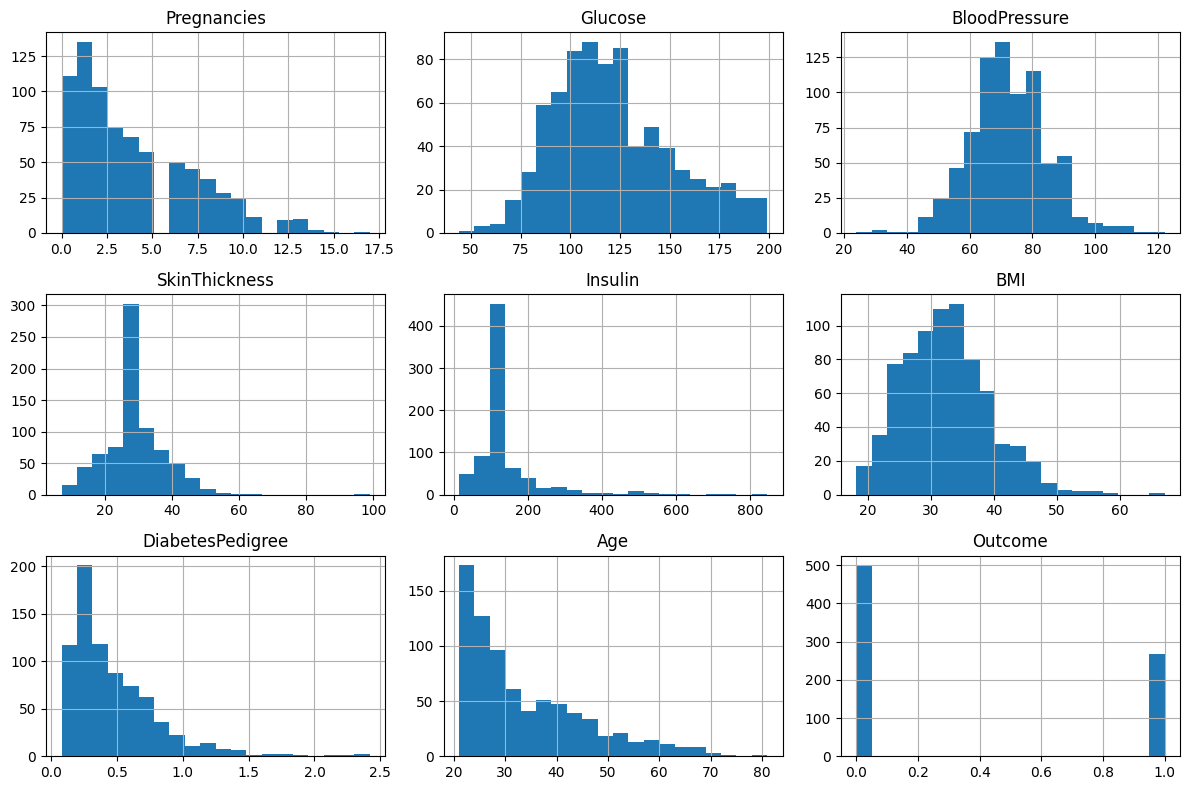

In [10]:
df.hist(figsize = (12,8), bins = 20)
plt.tight_layout()
plt.show()

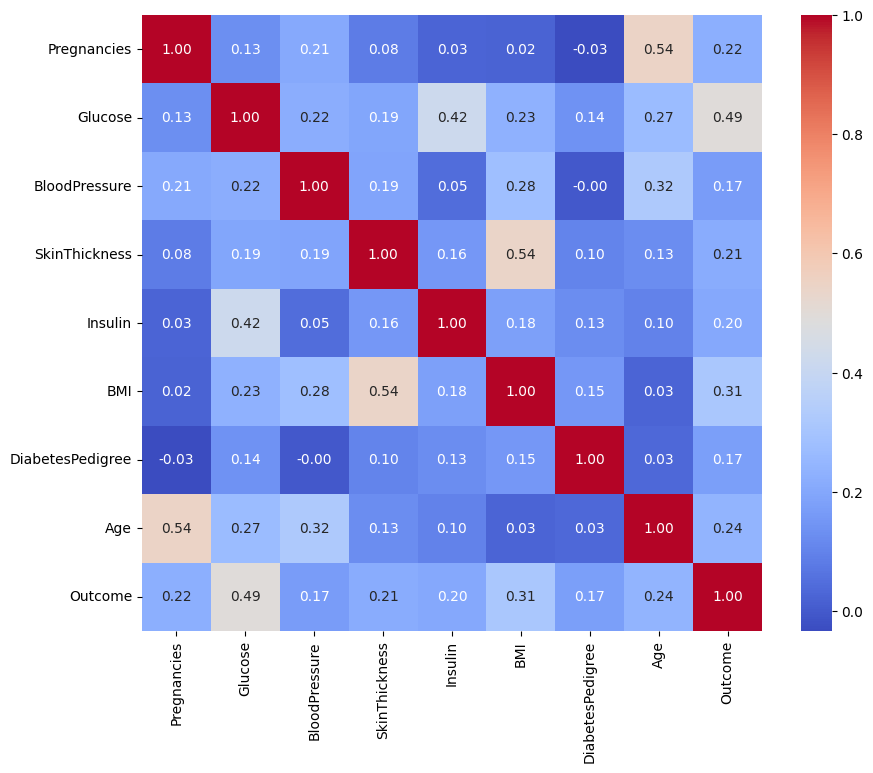

In [11]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap = "coolwarm")
plt.show()

#Model Preparation

Now, we check which model has the better accuracy score. Neural Networks do not perform well in small datasets. Nonetheless, we compare it with the linear models.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x = df.drop('Outcome', axis =1)
y = df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state = 42)

#scaling because Neural networks required scaled data
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric = 'logloss', random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
}

for name, model in models.items():
  model.fit(x_train_scaled, y_train)
  acc = accuracy_score(y_test, model.predict(x_test_scaled))
  print(f"{name} : {acc:.2f}")


Logistic Regression : 0.75
Random Forest : 0.73
XGBoost : 0.71
Neural Network : 0.72


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
# NN performs less accurately than other models like Logistic Regression. It is because NNs excel in datasets with hundreds of thousands of rows.

In [17]:
rl = LogisticRegression(max_iter=1000, random_state=42)
rl.fit(x_train_scaled, y_train)
y_pred = rl.predict(x_test_scaled)

In [18]:
#Now that the model has been trained, we print the metrics of our model

In [19]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
print(classification_report(y_test, y_pred, target_names = ['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81        99
    Diabetes       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



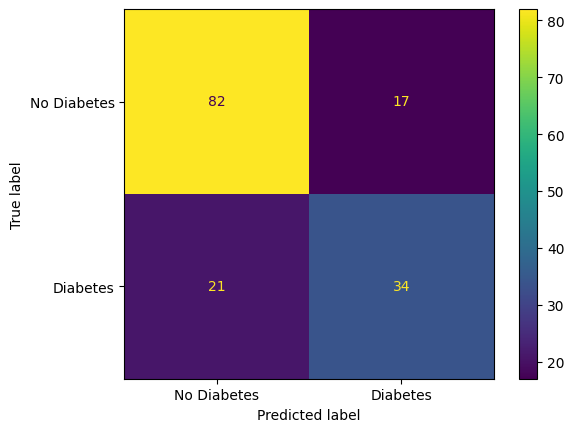

In [22]:
ConfusionMatrixDisplay.from_estimator(rl, x_test_scaled, y_test, display_labels= ['No Diabetes', 'Diabetes'])

In [23]:
# the logistic regression model has alarming number of false negatives i.e out of 55 diabetic people in the dataset,
# it correctly identified 34 but missed 21. This is a huge problem.
#Our recall is 0.62. In other words 38% of people are classified falsely.
#To solve this, we trade off precision for recall.

In [25]:
y_proba = model.predict_proba(x_test_scaled)[:, 1]
y_pred_sensitive = (y_proba >= 0.4).astype(int)

print(classification_report(y_test, y_pred_sensitive,
                             target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.82      0.73      0.77        99
    Diabetes       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154



In [26]:
# we now retrieve the roc curve for our model which is a better metric than accuracy

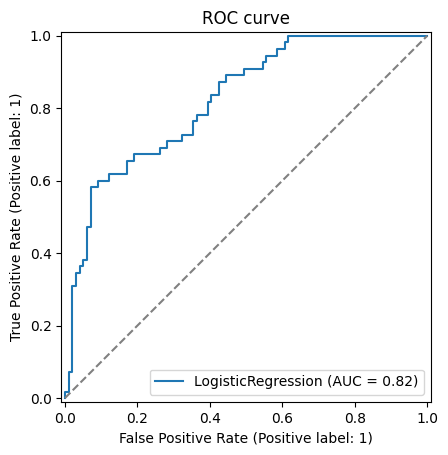

In [29]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
RocCurveDisplay.from_estimator(rl, x_test_scaled, y_test)
plt.title('ROC curve')
plt.plot([0,1],[0,1],'--', color='gray')  # random baseline
plt.show()